In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tensorflow.keras.datasets import mnist
from torch.utils.data import random_split
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from tqdm.notebook import tqdm

In [2]:
print(torch.cuda.is_available())

True


In [3]:
# Define transformation to apply to the data
data_transform = transforms.Compose([
    transforms.ToTensor(),  # Convert images to PyTorch tensors
    transforms.Normalize((0.5,), (0.5,))  # Normalize the pixel values to range [-1, 1]
])

# Download MNIST dataset and apply the transformation
train_dataset = datasets.MNIST(root='./data', train=True, transform=data_transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=data_transform, download=True)

dataset_size = len(train_dataset)

train_size = int(0.7 * dataset_size)
validation_size = dataset_size - train_size

train_subset, validation_subset = random_split(train_dataset, [train_size, validation_size])

# Define data loaders to load the data in batches during training and testing
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
validation_loader = DataLoader(validation_subset, batch_size=64, shuffle=False)

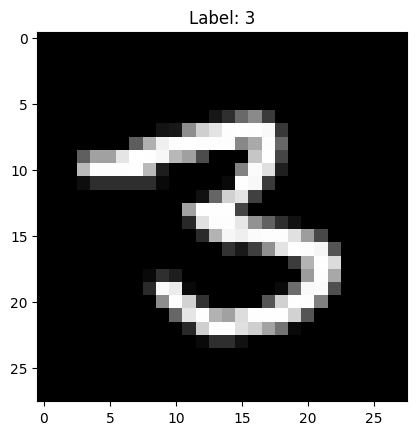

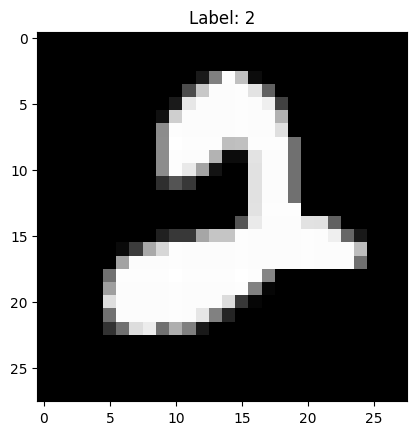

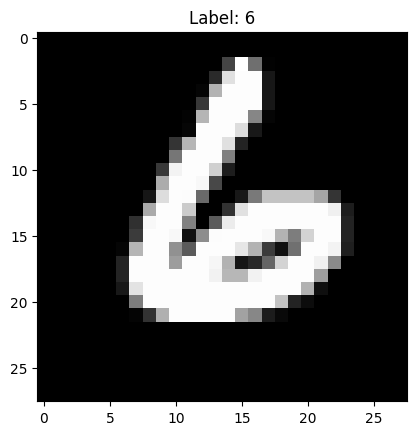

In [4]:
for images, labels in train_loader:
    for i in range(3):
        img = images[i].squeeze()
        plt.imshow(img, cmap='gray')
        plt.title(f"Label: {labels[i].item()}")
        plt.show()
    break

In [5]:
# Here we are adding convolution layer and fully connected layers in neural network
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1_layer = nn.Conv2d(1, 6, kernel_size=3)
        self.conv2_layer = nn.Conv2d(6, 12, kernel_size=5)
        self.conv3_layer = nn.Conv2d(12, 16, kernel_size=5, padding=1)
        self.linear1_layer = nn.Linear(16 * 2 * 2, 512)
        self.linear2_layer = nn.Linear(512, 256)
        self.linear3_layer = nn.Linear(256, 10)

    # Adding ReLU Activation function Max Pooling Layer
    def forward(self, inputs):
        new_input = torch.relu(self.conv1_layer(inputs))
        new_input = torch.max_pool2d(new_input, kernel_size=2, stride=2)
        new_input = torch.relu(self.conv2_layer(new_input))
        new_input = torch.max_pool2d(new_input, kernel_size=2, stride=2)
        new_input = torch.relu(self.conv3_layer(new_input))
        new_input = new_input.view(-1, 16 * 2 * 2)
        new_input = torch.relu(self.linear1_layer(new_input))
        new_input = self.linear2_layer(new_input)
        new_input = self.linear3_layer(new_input)
        return new_input


# Creating Model Instance
cnn_model = SimpleCNN()

In [6]:
# Define loss function and optimizer
loss_func = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

In [7]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

In [8]:
for epoch in range(20):
    cnn_model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in tqdm(train_loader, desc=f"Train - Epoch {epoch+1}"):
        optimizer.zero_grad()
        outputs = cnn_model(inputs)
        loss = loss_func(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)


    cnn_model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in tqdm(validation_loader, desc=f"Validation - Epoch {epoch+1}"):
            outputs = cnn_model(inputs)
            loss = loss_func(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(validation_loader)
    val_accuracy = correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)


    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Train - Epoch 1:   0%|          | 0/657 [00:00<?, ?it/s]

Validation - Epoch 1:   0%|          | 0/282 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 0.3042 | Val Loss: 0.0989


Train - Epoch 2:   0%|          | 0/657 [00:00<?, ?it/s]

Validation - Epoch 2:   0%|          | 0/282 [00:00<?, ?it/s]

...

Validation - Epoch 19:   0%|          | 0/282 [00:00<?, ?it/s]

Epoch 19 | Train Loss: 0.0134 | Val Loss: 0.0745


Train - Epoch 20:   0%|          | 0/657 [00:00<?, ?it/s]

Validation - Epoch 20:   0%|          | 0/282 [00:00<?, ?it/s]

Epoch 20 | Train Loss: 0.0139 | Val Loss: 0.0660


In [9]:
# Saving the model
mnist_model = {
    'epoch': epoch,
    'model_state_dict': cnn_model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': loss,
}
torch.save(mnist_model, 'mnist_model.pth')

In [10]:
# Loading the model
mnist_model = torch.load('mnist_model.pth')
cnn_model = SimpleCNN()
cnn_model.load_state_dict(mnist_model['model_state_dict'])
optimizer.load_state_dict(mnist_model['optimizer_state_dict'])
epoch = mnist_model['epoch']
loss = mnist_model['loss']
print(cnn_model)

SimpleCNN(
  (conv1_layer): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2_layer): Conv2d(6, 12, kernel_size=(5, 5), stride=(1, 1))
  (conv3_layer): Conv2d(12, 16, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
  (linear1_layer): Linear(in_features=64, out_features=512, bias=True)
  (linear2_layer): Linear(in_features=512, out_features=256, bias=True)
  (linear3_layer): Linear(in_features=256, out_features=10, bias=True)
)


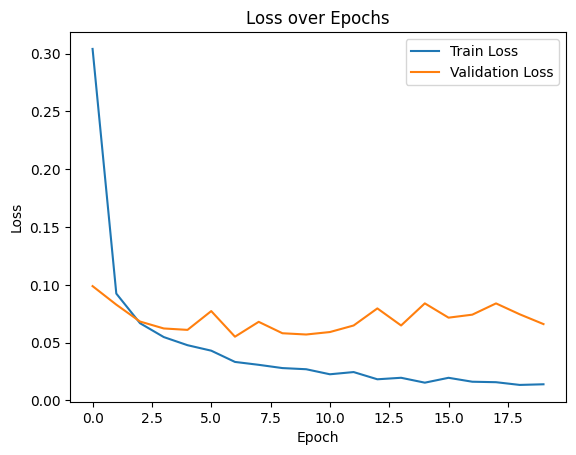

In [11]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.legend()

plt.show()

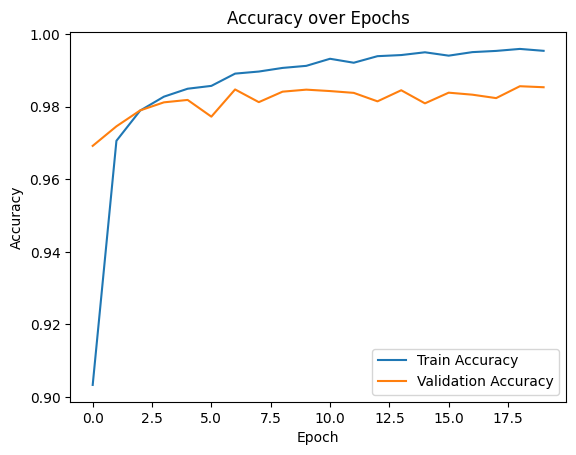

In [12]:
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy over Epochs")
plt.legend()

plt.show()

In [13]:
# Test model
correct_predictions = 0
total_samples = 0
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = cnn_model(inputs)
        _, predicted_labels = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted_labels == labels).sum().item()
        all_preds.extend(predicted_labels.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f"Accuracy of test set: {100 * correct_predictions / total_samples}%")

Accuracy of test set: 98.7%


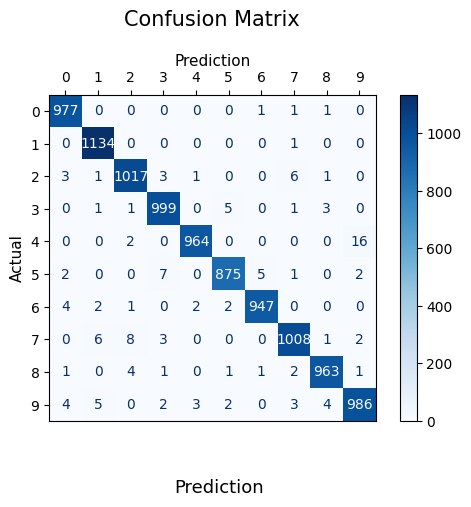

In [14]:
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)

plt.title('Confusion Matrix', fontsize=15, pad=20)
plt.xlabel('Prediction', fontsize=11)
plt.ylabel('Actual', fontsize=11)

plt.gca().xaxis.set_label_position('top')
plt.gca().xaxis.tick_top()

plt.gca().figure.subplots_adjust(bottom=0.2)
plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)

plt.show()